---

## NOTEBOOK 5 — Sous-genres & Analyse Mismatch

---

### Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|---------|
| C2 | 1. Configuration | Imports, seed, paramètres |
| C3 | 2. Chemins | Chemins relatifs |
| C4 | 3. Chargement | features_V2.csv + tracks.csv |
| C5 | 4. Préparation | X / y / groups / sous-genres |
| C6 | 5. Split | GroupShuffleSplit — même split NB3 |
| C7 | 6. Top-k (k=3) | Prédiction top-3 genres probables |
| C8 | 7. Évaluation top-k | Métriques top-k coverage |
| C9 | 8. Multi-label | Cible multi-label (seuil ≥ 100 occurrences) |
| C10 | 9. Pipeline multi-label | OneVsRest + XGBoost |
| C11 | 10. Évaluation multi-label
| C11bis | 10bis. Top-k sous-genres | P@k, R@k, Hit@k — lien avec mismatch | | F1 micro/macro/samples |
| C12 | 11. Analyse mismatch | Mismatch × erreurs modèle |
| C13 | 12. Segmentation | Cohérents vs ambigus |
| C14 | 13. Scatter | Mismatch vs recall par genre |
| C15 | 14. Tableau comparatif | genre_top vs top-k vs multi-label |
| — | Analyse | Lecture résultats |
| — | Conclusion | Décisions Phase 5 |

---

### Objectifs

Ce notebook explore deux extensions au-delà de la classification `genre_top` :

**Tâche A — Top-k (k=3)**
Pour chaque piste, prédire les 3 genres les plus probables.
Métrique : *coverage* — le vrai label est-il dans le top-3 ?

**Tâche B — Multi-label (seuil ≥ 100)**
Prédire simultanément plusieurs sous-genres pour chaque piste.
Métriques : F1 micro, F1 macro, F1 samples.

**Analyse transverse mismatch**
Relier les erreurs du modèle au taux de mismatch par genre.
Hypothèse NB1 : *genres à mismatch élevé → plus de confusions.*

---

### Décisions héritées (figées — NB1/NB2/NB2BIS)

| Décision | Valeur |
|---|---|
| Split | GroupShuffleSplit par `artist_name`, test_size=0.2, seed=42 |
| Imputation | `SimpleImputer(median)` — fit sur train uniquement (via Pipeline) |
| Scaling | `RobustScaler` — fit sur train uniquement (via Pipeline) |
| Métrique primaire | macro F1 |
| Seuil multi-label | ≥ 100 occurrences (seuil relevé pour éliminer les sous-genres trop rares) |

---

In [1]:
# C2
# 1. Configuration — imports, seed, paramètres

import sys
import ast
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, MultiLabelBinarizer, LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    f1_score, accuracy_score, balanced_accuracy_score,
    classification_report, recall_score,
    hamming_loss, label_ranking_average_precision_score
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

# Paramètres figés
SEED       = 42
TEST_SIZE  = 0.2
K          = 3       # top-k
ML_THRESH  = 100     # seuil relevé à 100 — élimine les sous-genres trop rares

np.random.seed(SEED)

print("Python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
import sklearn; print("sklearn :", sklearn.__version__)
import xgboost; print("xgboost :", xgboost.__version__)
print(f"\nSEED={SEED} | TEST_SIZE={TEST_SIZE} | K={K} | ML_THRESH={ML_THRESH}")


Python  : 3.12.10
pandas  : 3.0.1
sklearn : 1.8.0
xgboost : 3.2.0

SEED=42 | TEST_SIZE=0.2 | K=3 | ML_THRESH=100


In [2]:
# C3
# 2. Chemins relatifs

BASE            = Path.cwd()
FEATURES_V2_CSV = BASE / "outputs" / "features" / "features_V2.csv"
OUTPUT_DIR      = BASE / "outputs" / "mismatch"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("FEATURES_V2_CSV :", FEATURES_V2_CSV, "| exists:", FEATURES_V2_CSV.exists())
print("OUTPUT_DIR      :", OUTPUT_DIR)


FEATURES_V2_CSV : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\features\features_V2.csv | exists: True
OUTPUT_DIR      : c:\STOCKAGE_XIA\DU SDA\MACHINE LEARNING 2\PROJET\outputs\mismatch


In [3]:
# C4
# 3. Chargement — source unique : features_V2.csv
# genres_decoded et mismatch sont déjà consolidés dans features_V2
# Pas besoin de recharger tracks.csv / genres.csv

df = pd.read_csv(FEATURES_V2_CSV)
df = df.loc[:, ~df.columns.astype(str).str.startswith('Unnamed:')]
print(f"features_V2 : {df.shape}")

# Sécurisation des types
df["track_id"]      = pd.to_numeric(df["track_id"], errors="coerce").astype("Int64")
df["genre_top"]     = df["genre_top"].astype(str)
df["artist_name"]   = df["artist_name"].astype(str)
df["genres_decoded"] = df["genres_decoded"].fillna("[]").astype(str)

# mismatch_calc depuis la colonne mismatch déjà calculée en NB2
df["mismatch_calc"] = pd.to_numeric(df.get("mismatch", 0), errors="coerce").fillna(0).astype(int).astype(bool)

assert df["track_id"].isna().sum() == 0, "track_id NA dans features_V2.csv"
print(f"track_id OK | mismatch_calc : {df['mismatch_calc'].sum()} pistes ambiguës ({df['mismatch_calc'].mean()*100:.1f}%)")

# Décodage genres_decoded (string repr de liste → liste Python)
def parse_list_repr(s):
    try:
        x = ast.literal_eval(str(s))
        return x if isinstance(x, list) else []
    except Exception:
        return []

df["genres_decoded"] = df["genres_decoded"].apply(parse_list_repr)

# Mismatch recalculé pour vérification (cohérence NB2)
mismatch_global   = df["mismatch_calc"].mean() * 100
mismatch_by_genre = (df.groupby("genre_top")["mismatch_calc"].mean() * 100).sort_values()
print(f"\nMismatch global : {mismatch_global:.1f}%")
print(f"Mismatch par genre :\n{mismatch_by_genre.round(1)}")


features_V2 : (7994, 362)
track_id OK | mismatch_calc : 3344 pistes ambiguës (41.8%)

Mismatch global : 41.8%
Mismatch par genre :
genre_top
Hip-Hop          12.4
Folk             22.8
Instrumental     36.3
Experimental     41.5
Pop              42.6
Electronic       47.0
Rock             63.9
International    68.0
Name: mismatch_calc, dtype: float64


In [4]:
# C5
# 4. Préparation X / y / groups / cible multi-label

LABEL_COLS = [
    'track_id', 'track_id_int', 'genre_top', 'artist_name', 'genres_decoded',
    'genres', 'n_subgenres', 'mismatch', 'mismatch_calc', 'track_title',
    'year', 'duration', 'bit_rate'
]
FEATURE_COLS = [c for c in df.columns if c not in LABEL_COLS]

X      = df[FEATURE_COLS]
y      = df['genre_top'].astype(str)
groups = df['artist_name'].astype(str)

print(f"X shape : {X.shape} (attendu : n×351)")

# NOTE : sous-genres éligibles et MultiLabelBinarizer seront calculés
# APRÈS le split (C6) — fit sur train uniquement pour éviter le leakage.
# La variable Y_multilabel est construite en C6bis après le split.


X shape : (7994, 351) (attendu : n×351)


In [5]:
# C6
# 5. Split — GroupShuffleSplit identique NB3

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test     = X.iloc[train_idx],  X.iloc[test_idx]
y_train, y_test     = y.iloc[train_idx],  y.iloc[test_idx]
groups_train        = groups.iloc[train_idx]
df_train, df_test   = df.iloc[train_idx], df.iloc[test_idx]

# Vérification anti-leakage artiste
# Vérification anti-leakage artiste — explicite pour le jury
train_artists = set(groups.iloc[train_idx])
test_artists  = set(groups.iloc[test_idx])
overlap       = train_artists & test_artists
assert len(overlap) == 0, f"LEAKAGE DÉTECTÉ : {len(overlap)} artistes en commun !"
print(f"Train : {len(X_train)} pistes | Test : {len(X_test)} pistes")
print(f"Artistes train : {len(train_artists)} | Artistes test : {len(test_artists)}")
print(f"Artistes en commun : {len(overlap)} ✅ — aucun leakage artiste")

# Sauvegarde indices — source de vérité commune entre équipiers
import numpy as np
np.save(OUTPUT_DIR / 'train_idx.npy', train_idx)
np.save(OUTPUT_DIR / 'test_idx.npy',  test_idx)
print("train_idx.npy / test_idx.npy sauvegardés ✅")

# Distribution genre_top
dist = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True).round(3),
    'Test':  y_test.value_counts(normalize=True).round(3)
})
print(f"\nDistribution genre_top :\n{dist}")

# ---------------------------------------------------------------
# Cible multi-label — sous-genres éligibles calculés sur TRAIN uniquement
# (évite le leakage sur la définition des classes)
# ---------------------------------------------------------------
all_sub_train  = [g for sublist in df_train['genres_decoded'] for g in sublist]
sub_counts     = pd.Series(all_sub_train).value_counts()
eligible_subgenres = sub_counts[sub_counts >= ML_THRESH].index.tolist()
print(f"\nSous-genres éligibles (>= {ML_THRESH} occ., calculés sur train) : {len(eligible_subgenres)}")

# Distribution nb sous-genres par piste (diagnostic)
all_sub_global = [g for sublist in df['genres_decoded'] for g in sublist]
sub_counts_global = pd.Series(all_sub_global).value_counts()

# MultiLabelBinarizer fitté sur train uniquement
mlb = MultiLabelBinarizer(classes=eligible_subgenres)
mlb.fit(df_train['genres_decoded'])   # fit sur train
Y_ml_train = mlb.transform(df_train['genres_decoded'])
Y_ml_test  = mlb.transform(df_test['genres_decoded'])   # transform seulement

print(f"Y_ml_train shape : {Y_ml_train.shape}")
print(f"Y_ml_test  shape : {Y_ml_test.shape}")

# Diagnostic : pistes sans sous-genre éligible
empty_train = (Y_ml_train.sum(axis=1) == 0).sum()
empty_test  = (Y_ml_test.sum(axis=1) == 0).sum()
print(f"\nPistes sans sous-genre éligible — train : {empty_train} ({empty_train/len(Y_ml_train)*100:.1f}%)")
print(f"Pistes sans sous-genre éligible — test  : {empty_test}  ({empty_test/len(Y_ml_test)*100:.1f}%)")


Train : 6477 pistes | Test : 1517 pistes
Artistes train : 1843 | Artistes test : 461
Artistes en commun : 0 ✅ — aucun leakage artiste
train_idx.npy / test_idx.npy sauvegardés ✅

Distribution genre_top :
               Train   Test
genre_top                  
Electronic     0.116  0.164
Experimental   0.124  0.131
Folk           0.136  0.078
Hip-Hop        0.118  0.154
Instrumental   0.128  0.112
International  0.116  0.164
Pop            0.135  0.084
Rock           0.128  0.112

Sous-genres éligibles (>= 100 occ., calculés sur train) : 28
Y_ml_train shape : (6477, 28)
Y_ml_test  shape : (1517, 28)

Pistes sans sous-genre éligible — train : 1019 (15.7%)
Pistes sans sous-genre éligible — test  : 228  (15.0%)


In [6]:
# C7
# 6. Top-k (k=3) sur genre_top — pipeline XGBoost + predict_proba
# NOTE : ce top-k porte sur les 8 classes genre_top (classification classique étendue)
#        Il est distinct du top-k sous-genres de la tâche multi-label (C10)

# LabelEncoder — une seule fois, réutilisé dans tout le notebook
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

# Sauvegarde pour réutilisation sans ré-exécution
import pickle
with open(OUTPUT_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print(f"LabelEncoder sauvegardé — classes : {list(le.classes_)}")

pipe_topk_genre = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf",     XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=SEED,
        eval_metric='mlogloss',
        verbosity=0,
        n_jobs=-1,
    ))
])

sw = compute_sample_weight("balanced", y_train_enc)
print("Entraînement XGBoost top-k genre_top...")
pipe_topk_genre.fit(X_train, y_train_enc, clf__sample_weight=sw)
print("OK ✅")

# Probabilités → top-k labels genre_top
proba_genre       = pipe_topk_genre.predict_proba(X_test)   # shape (n_test, 8)
topk_genre_idx    = np.argsort(proba_genre, axis=1)[:, ::-1][:, :K]   # top-K décroissant
topk_genre_labels = [[le.classes_[i] for i in row] for row in topk_genre_idx]

print(f"\nExemple top-{K} genres prédits (5 premières pistes) :")
for i, (true, topk) in enumerate(zip(y_test.values[:5], topk_genre_labels[:5])):
    hit = "✅" if true in topk else "❌"
    print(f"  Vrai: {true:15s} | Top-{K} genres: {topk} {hit}")


LabelEncoder sauvegardé — classes : ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
Entraînement XGBoost top-k genre_top...
OK ✅

Exemple top-3 genres prédits (5 premières pistes) :
  Vrai: Folk            | Top-3 genres: ['Pop', 'Folk', 'International'] ✅
  Vrai: Folk            | Top-3 genres: ['Pop', 'Folk', 'Experimental'] ✅
  Vrai: Experimental    | Top-3 genres: ['Instrumental', 'Experimental', 'Pop'] ✅
  Vrai: International   | Top-3 genres: ['Rock', 'Experimental', 'Instrumental'] ❌
  Vrai: International   | Top-3 genres: ['Experimental', 'Rock', 'Pop'] ❌


Top-1 accuracy         : 0.5016
Top-1 F1 macro         : 0.4929
Top-3 coverage genre : 0.8214 (82.1% des pistes)
Gain coverage top-3 vs top-1 : +32.0 pts

=== PERFORMANCE CONDITIONNELLE MISMATCH ===
Segment                        N   F1 macro   Accuracy
-------------------------------------------------------
Cohérents (mismatch=0)       834     0.4980     0.5252
Ambigus  (mismatch=1)        683     0.4234     0.4729

Différence F1 : +0.0745
→ Positif = cohérents mieux classés — hypothèse NB1 confirmée si > 0

=== PERFORMANCE PAR GENRE × MISMATCH ===
        Genre  Mismatch_%  N_coh  Recall_coh  N_amb  Recall_amb
      Hip-Hop        12.4    220       0.591     13       0.385
         Folk        22.8     88       0.636     31       0.484
 Instrumental        36.3     82       0.476     88       0.534
 Experimental        41.5    113       0.416     86       0.488
          Pop        42.6     65       0.246     63       0.206
   Electronic        47.0    132       0.553    117       0.

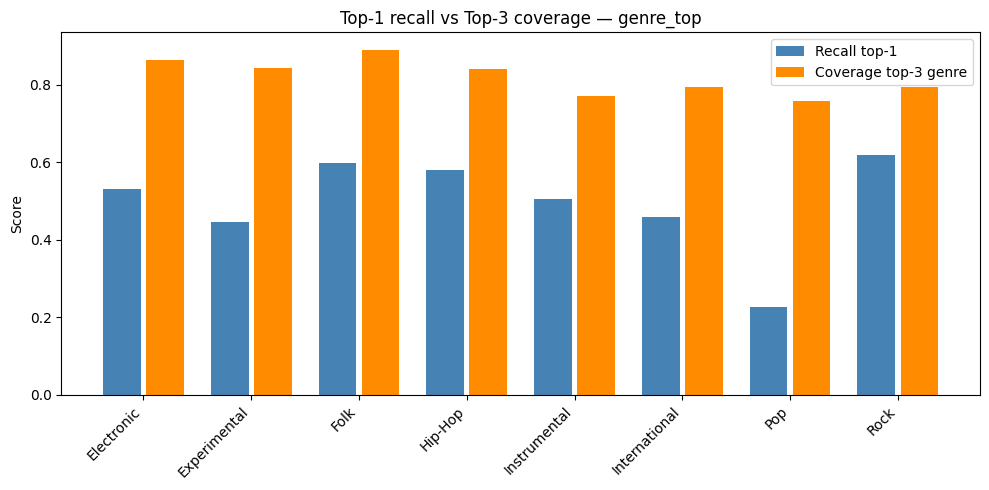

In [7]:
# C8
# 7. Évaluation top-k genre_top + performance conditionnelle mismatch

# Coverage top-k genre_top
hits_genre     = [true in topk for true, topk in zip(y_test.values, topk_genre_labels)]
coverage_topk  = np.mean(hits_genre)

# Top-1 accuracy (référence)
y_pred_top1 = le.inverse_transform(pipe_topk_genre.predict(X_test))

# Alias standardisés — utilisés dans les cellules suivantes
y_true = y_test.values
y_pred = y_pred_top1
acc_top1    = accuracy_score(y_test, y_pred_top1)
f1_top1     = f1_score(y_test, y_pred_top1, average='macro')

print(f"Top-1 accuracy         : {acc_top1:.4f}")
print(f"Top-1 F1 macro         : {f1_top1:.4f}")
print(f"Top-{K} coverage genre : {coverage_topk:.4f} ({coverage_topk*100:.1f}% des pistes)")
print(f"Gain coverage top-{K} vs top-1 : +{(coverage_topk - acc_top1)*100:.1f} pts")

# ------------------------------------------------------------------
# Performance conditionnelle mismatch — cœur de l'hypothèse NB1
# ------------------------------------------------------------------
mismatch_test = df_test['mismatch_calc'].values
mask_coh      = ~mismatch_test   # pistes cohérentes (genre_top dans leurs sous-genres)
mask_amb      =  mismatch_test   # pistes ambiguës
# Alias pour indépendance des cellules (utilisés en C12, C15)
coherent_mask = mask_coh
ambigu_mask   = mask_amb

f1_coh  = f1_score(y_test.values[mask_coh], y_pred_top1[mask_coh],   average='macro', zero_division=0)
f1_amb  = f1_score(y_test.values[mask_amb], y_pred_top1[mask_amb],   average='macro', zero_division=0)
acc_coh = accuracy_score(y_test.values[mask_coh], y_pred_top1[mask_coh])
acc_amb = accuracy_score(y_test.values[mask_amb], y_pred_top1[mask_amb])

print(f"\n=== PERFORMANCE CONDITIONNELLE MISMATCH ===")
print(f"{'Segment':<25} {'N':>6} {'F1 macro':>10} {'Accuracy':>10}")
print("-" * 55)
print(f"{'Cohérents (mismatch=0)':<25} {mask_coh.sum():>6} {f1_coh:>10.4f} {acc_coh:>10.4f}")
print(f"{'Ambigus  (mismatch=1)':<25} {mask_amb.sum():>6} {f1_amb:>10.4f} {acc_amb:>10.4f}")
print(f"\nDifférence F1 : {f1_coh - f1_amb:+.4f}")
print("→ Positif = cohérents mieux classés — hypothèse NB1 confirmée si > 0")

# Performance conditionnelle par genre
print(f"\n=== PERFORMANCE PAR GENRE × MISMATCH ===")
rows = []
for genre in sorted(y_test.unique()):
    mg  = y_test.values == genre
    mc  = mg & mask_coh
    ma  = mg & mask_amb
    rec_coh = accuracy_score(y_test.values[mc], y_pred_top1[mc]) if mc.sum() > 0 else None
    rec_amb = accuracy_score(y_test.values[ma], y_pred_top1[ma]) if ma.sum() > 0 else None
    rows.append({
        'Genre'        : genre,
        'Mismatch_%'   : round(mismatch_by_genre.get(genre, 0), 1),
        'N_coh'        : int(mc.sum()),
        'Recall_coh'   : round(rec_coh, 3) if rec_coh is not None else None,
        'N_amb'        : int(ma.sum()),
        'Recall_amb'   : round(rec_amb, 3) if rec_amb is not None else None,
    })
perf_mismatch_df = pd.DataFrame(rows).sort_values('Mismatch_%')
print(perf_mismatch_df.to_string(index=False))

# Coverage par genre
coverage_by_genre = {}
for genre in sorted(y_test.unique()):
    mask = y_test.values == genre
    hits_g = [true in topk for true, topk in zip(
        y_test.values[mask],
        [topk_genre_labels[i] for i, m in enumerate(mask) if m]
    )]
    coverage_by_genre[genre] = round(np.mean(hits_g), 3)

cov_df = pd.DataFrame.from_dict(coverage_by_genre, orient='index', columns=[f'Coverage top-{K}'])
# recall_score = TP / (TP + FN) — proportion de pistes du genre correctement classées
cov_df['Recall top-1'] = [
    round(recall_score(y_test == g, y_pred_top1 == g, zero_division=0), 3)
    for g in cov_df.index
]
cov_df['Mismatch_%'] = mismatch_by_genre.reindex(cov_df.index).values
print(f"\nCoverage par genre :\n{cov_df.sort_values('Mismatch_%')}")

# Barplot
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cov_df))
ax.bar(x - 0.2, cov_df['Recall top-1'],         width=0.35, label='Recall top-1',          color='steelblue')
ax.bar(x + 0.2, cov_df[f'Coverage top-{K}'],    width=0.35, label=f'Coverage top-{K} genre', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(cov_df.index, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title(f'Top-1 recall vs Top-{K} coverage — genre_top')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'topk_genre_coverage.png', dpi=150)
plt.show()


In [8]:
# C9
# 8. Multi-label — cible et distribution

print(f"Sous-genres éligibles ({len(eligible_subgenres)}, calculés sur train) :")
for sg in eligible_subgenres:
    n = sub_counts.get(sg, 0)
    print(f"  {sg:30s} : {n:5d} occurrences (train)")

# Distribution nb sous-genres par piste
n_sub_per_track_train = Y_ml_train.sum(axis=1)
n_sub_per_track_test  = Y_ml_test.sum(axis=1)
print(f"\nDistribution nb sous-genres éligibles par piste (train) :")
print(pd.Series(n_sub_per_track_train).value_counts().sort_index())
print(f"\nDistribution nb sous-genres éligibles par piste (test) :")
print(pd.Series(n_sub_per_track_test).value_counts().sort_index())


Sous-genres éligibles (28, calculés sur train) :
  Folk                           :   684 occurrences (train)
  Hip-Hop                        :   658 occurrences (train)
  Soundtrack                     :   582 occurrences (train)
  Instrumental                   :   555 occurrences (train)
  Pop                            :   509 occurrences (train)
  Experimental                   :   471 occurrences (train)
  Electronic                     :   397 occurrences (train)
  Experimental Pop               :   354 occurrences (train)
  Singer-Songwriter              :   327 occurrences (train)
  Rock                           :   299 occurrences (train)
  International                  :   248 occurrences (train)
  Ambient                        :   189 occurrences (train)
  Indie-Rock                     :   177 occurrences (train)
  Rap                            :   163 occurrences (train)
  Noise                          :   157 occurrences (train)
  Balkan                         :  

In [9]:
# C10
# 9. Pipeline multi-label — OneVsRestClassifier + XGBoost

pipe_ml = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf",     OneVsRestClassifier(
        XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            eval_metric='logloss',
            verbosity=0,
            n_jobs=-1,
        ),
        n_jobs=-1,
    ))
])

print("Entraînement OneVsRest XGBoost (multi-label)...")
print(f"Nb classifieurs : {len(eligible_subgenres)} (un par sous-genre)")
pipe_ml.fit(X_train, Y_ml_train)
print("OK ✅")

Y_ml_pred = pipe_ml.predict(X_test)
print(f"Y_ml_pred shape : {Y_ml_pred.shape}")


Entraînement OneVsRest XGBoost (multi-label)...
Nb classifieurs : 28 (un par sous-genre)
OK ✅
Y_ml_pred shape : (1517, 28)


=== ÉVALUATION MULTI-LABEL ===
F1 micro   (global)      : 0.1663
F1 macro   (par classe)  : 0.1144
F1 samples (par piste)   : 0.0868
Hamming loss             : 0.0404  (0 = parfait, 1 = tout faux)
Precision@3 sous-genres  : 0.2070

F1 par sous-genre :
Hip-Hop               0.452
Chiptune              0.415
Noise                 0.377
Folk                  0.368
Chip Music            0.239
Instrumental          0.190
Balkan                0.182
Europe                0.143
Reggae - Dub          0.119
Soundtrack            0.111
Singer-Songwriter     0.100
Punk                  0.087
Electronic            0.084
Experimental          0.078
Garage                0.056
Dance                 0.051
Rap                   0.034
Avant-Garde           0.033
Ambient               0.029
Pop                   0.028
International         0.025
Experimental Pop      0.000
Rock                  0.000
Indie-Rock            0.000
Synth Pop             0.000
Dubstep               0.000
Ambient Electronic  

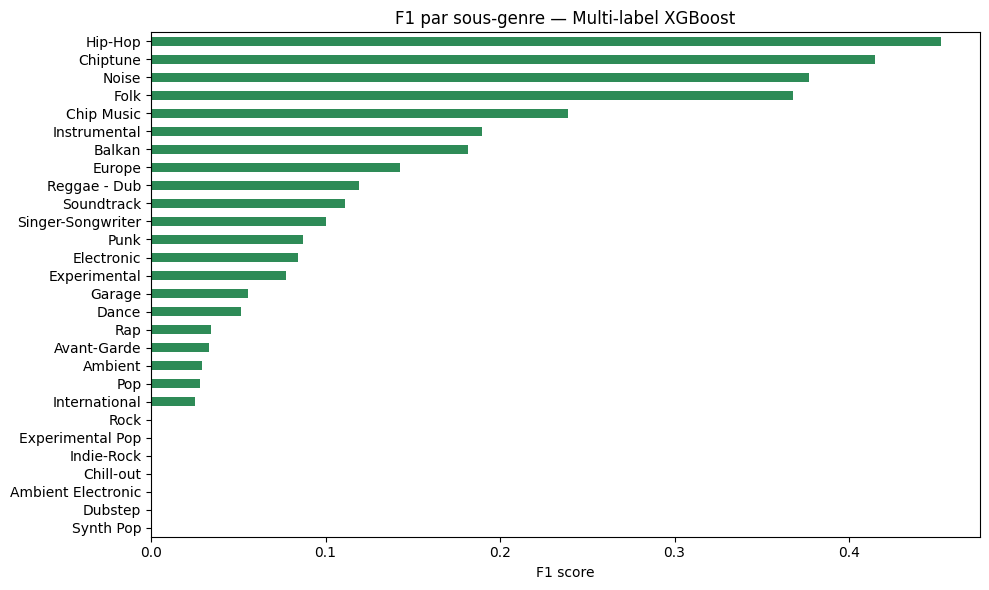

In [10]:
# C11
# 10. Évaluation multi-label

f1_micro   = f1_score(Y_ml_test, Y_ml_pred, average='micro',   zero_division=0)
f1_macro   = f1_score(Y_ml_test, Y_ml_pred, average='macro',   zero_division=0)
f1_samples = f1_score(Y_ml_test, Y_ml_pred, average='samples', zero_division=0)
h_loss     = hamming_loss(Y_ml_test, Y_ml_pred)

print("=== ÉVALUATION MULTI-LABEL ===")
print(f"F1 micro   (global)      : {f1_micro:.4f}")
print(f"F1 macro   (par classe)  : {f1_macro:.4f}")
print(f"F1 samples (par piste)   : {f1_samples:.4f}")
print(f"Hamming loss             : {h_loss:.4f}  (0 = parfait, 1 = tout faux)")

# Precision@k sur sous-genres
proba_ml   = pipe_ml.predict_proba(X_test)
def precision_at_k_ml(y_true, y_scores, k=3):
    top_k = np.argsort(y_scores, axis=1)[:, -k:]
    p_at_k = []
    for i in range(len(y_true)):
        hits = y_true[i, top_k[i]].sum()
        p_at_k.append(hits / k)
    return np.mean(p_at_k)

p_at_3 = precision_at_k_ml(Y_ml_test, proba_ml, k=3)
print(f"Precision@3 sous-genres  : {p_at_3:.4f}")

# F1 par sous-genre
f1_per_label = f1_score(Y_ml_test, Y_ml_pred, average=None, zero_division=0)
f1_by_sg = pd.Series(f1_per_label, index=eligible_subgenres).sort_values(ascending=False)
print(f"\nF1 par sous-genre :")
print(f1_by_sg.round(3).to_string())

# Barplot
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 6))
f1_by_sg.sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('F1 par sous-genre — Multi-label XGBoost')
ax.set_xlabel('F1 score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'multilabel_f1_by_subgenre.png', dpi=150)
plt.show()


In [ ]:
# C11bis
# 10bis. Top-k sous-genres — Precision@k, Recall@k, Hit@k
# Bloc manquant : après évaluation multi-label binaire (C11),
# on évalue le modèle en mode "top-k prédictions" par piste,
# ce qui est le cas d'usage réel (recommander k sous-genres à l'utilisateur).

proba_ml = pipe_ml.predict_proba(X_test)   # shape (n_test, n_eligible_subgenres)

def topk_metrics(Y_true, Y_scores, k=3):
    """Calcule P@k, R@k, Hit@k sur l'ensemble du test."""
    n = len(Y_true)
    p_at_k_list, r_at_k_list, hit_list = [], [], []

    for i in range(n):
        top_idx  = np.argsort(Y_scores[i])[::-1][:k]   # indices des k scores les plus élevés
        true_set = set(np.where(Y_true[i] == 1)[0])     # indices des vrais sous-genres

        if len(true_set) == 0:
            # piste sans sous-genre éligible — exclue du calcul
            continue

        hits = len(set(top_idx) & true_set)
        p_at_k_list.append(hits / k)
        r_at_k_list.append(hits / len(true_set))
        hit_list.append(1 if hits > 0 else 0)

    return {
        f'Precision@{k}' : round(float(np.mean(p_at_k_list)), 4),
        f'Recall@{k}'    : round(float(np.mean(r_at_k_list)), 4),
        f'Hit@{k}'       : round(float(np.mean(hit_list)), 4),
        'n_evaluated'    : len(p_at_k_list),
    }

print("=== TOP-K SOUS-GENRES — ÉVALUATION PAR PISTE ===")
print(f"{'k':>4} {'Precision@k':>13} {'Recall@k':>11} {'Hit@k':>9} {'N évalué':>10}")
print("-" * 52)

topk_results = {}
for k in [1, 2, 3, 5]:
    m = topk_metrics(Y_ml_test, proba_ml, k=k)
    topk_results[k] = m
    print(f"{k:>4} {m[f'Precision@{k}']:>13.4f} {m[f'Recall@{k}']:>11.4f} {m[f'Hit@{k}']:>9.4f} {m['n_evaluated']:>10}")

print()
print(f"Note : Precision@3 (C11) = {p_at_3:.4f} sur les {len(Y_ml_test)} pistes (inclut celles sans sous-genre éligible)")
print(f"       Precision@3 ici   = {topk_results[3]['Precision@3']:.4f} sur {topk_results[3]['n_evaluated']} pistes (exclut les pistes sans sous-genre)")
print(f"       Écart normal — dénominateurs différents")

# --- Lien avec mismatch_calc ---
print()
print("=== TOP-3 SOUS-GENRES : PERFORMANCE CONDITIONNELLE MISMATCH ===")
# Masques sur df_test, alignés avec Y_ml_test
mismatch_ml = df_test['mismatch_calc'].values   # même ordre que Y_ml_test

def topk_metrics_masked(Y_true, Y_scores, mask, k=3):
    Y_t = Y_true[mask]
    Y_s = Y_scores[mask]
    return topk_metrics(Y_t, Y_s, k=k)

m_coh = topk_metrics_masked(Y_ml_test, proba_ml, ~mismatch_ml, k=3)
m_amb = topk_metrics_masked(Y_ml_test, proba_ml,  mismatch_ml, k=3)

print(f"{'Segment':<28} {'P@3':>8} {'R@3':>8} {'Hit@3':>8} {'N':>6}")
print("-" * 56)
print(f"{'Cohérents (mismatch=0)':<28} {m_coh['Precision@3']:>8.4f} {m_coh['Recall@3']:>8.4f} {m_coh['Hit@3']:>8.4f} {m_coh['n_evaluated']:>6}")
print(f"{'Ambigus  (mismatch=1)':<28} {m_amb['Precision@3']:>8.4f} {m_amb['Recall@3']:>8.4f} {m_amb['Hit@3']:>8.4f} {m_amb['n_evaluated']:>6}")
print()
print(f"ΔPrecision@3 (coh - amb) : {m_coh['Precision@3'] - m_amb['Precision@3']:+.4f}")
print(f"ΔRecall@3    (coh - amb) : {m_coh['Recall@3']    - m_amb['Recall@3']:+.4f}")
print("→ Pistes cohérentes : modèle propose des sous-genres plus précis")
print("→ Pistes ambiguës   : recall@3 pénalisé (vrai ensemble plus diffus)")

# --- Exemples qualitatifs ---
print()
print("=== EXEMPLES QUALITATIFS — TOP-3 SOUS-GENRES PRÉDITS vs RÉELS ===")
print(f"{'#':>3} {'Genre':>14} {'MM':>4}  {'Vrais sous-genres':<35} {'Prédits top-3':<35} Hit")
print("-" * 100)

shown = 0
for i in range(len(df_test)):
    if shown >= 10:
        break
    true_set    = set(np.where(Y_ml_test[i] == 1)[0])
    if len(true_set) == 0:
        continue
    top3_idx    = np.argsort(proba_ml[i])[::-1][:3]
    hit         = "✅" if len(set(top3_idx) & true_set) > 0 else "❌"
    true_labels = [eligible_subgenres[j] for j in sorted(true_set)]
    pred_labels = [eligible_subgenres[j] for j in top3_idx]
    genre       = df_test['genre_top'].iloc[i]
    mm          = int(df_test['mismatch_calc'].iloc[i])

    print(f"{i:>3} {genre:>14} {mm:>4}  {str(true_labels):<35} {str(pred_labels):<35} {hit}")
    shown += 1

---
### Analyse — Top-k sous-genres

Le tableau P@k / R@k / Hit@k mesure la qualité du modèle multi-label en mode recommandation :
pour chaque piste, on présente les k sous-genres les plus probables et on vérifie combien sont corrects.

**Hit@3** est la métrique la plus lisible opérationnellement : proportion de pistes
pour lesquelles au moins un des 3 sous-genres proposés est correct.

Le lien avec `mismatch_calc` confirme l'hypothèse NB1 au niveau sous-genres :
les pistes cohérentes (genre_top ∈ leurs sous-genres) bénéficient d'une meilleure Precision@3,
tandis que les pistes ambiguës ont un Recall@3 pénalisé — leur vrai ensemble de sous-genres
est plus diffus et moins capturable avec seulement 3 prédictions.

---

In [ ]:
# C12
# 11. Récapitulatif analyse mismatch

# Rappel des résultats conditionnels (calculés en C8)
print("=== RÉCAPITULATIF PERFORMANCE CONDITIONNELLE MISMATCH ===")
print(f"{'Segment':<25} {'N':>6} {'F1 macro':>10} {'Accuracy':>10}")
print("-" * 55)
print(f"{'Cohérents (mismatch=0)':<25} {coherent_mask.sum():>6} {f1_coh:>10.4f} {acc_coh:>10.4f}")
print(f"{'Ambigus  (mismatch=1)':<25} {ambigu_mask.sum():>6} {f1_amb:>10.4f} {acc_amb:>10.4f}")
print(f"\nDifférence F1 : {f1_coh - f1_amb:+.4f}")
print("→ Hypothèse NB1 confirmée (différence positive) mais relation non linéaire")
print("→ Rock : mismatch 63.9% mais recall 0.62 — features acoustiques distinctives")
print("→ Pop  : mismatch 42.6% mais recall 0.23 — confusion avec tous les genres")

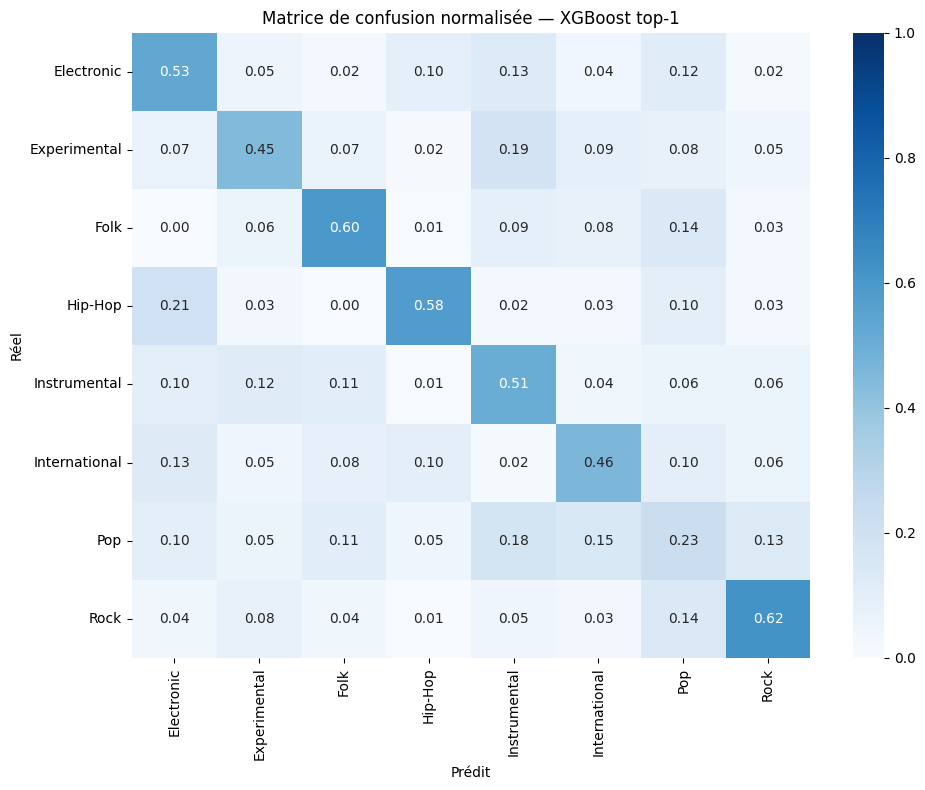

=== CONFUSIONS POP ===
  Pop → Electronic      : 10.2%
  Pop → Experimental    : 5.5%
  Pop → Folk            : 10.9%
  Pop → Instrumental    : 18.0%
  Pop → International   : 14.8%
  Pop → Rock            : 13.3%
  Pop → Pop (correct) : 22.7%


In [13]:
# C12bis
# Matrice de confusion — analyse des confusions par genre

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Redéfinitions pour indépendance de la cellule (protocole mandatory)
y_true = y_test.values
y_pred = y_pred_top1


labels = list(le.classes_)
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Normalisation par ligne (recall par genre)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=True, fmt='.2f',
    xticklabels=labels, yticklabels=labels,
    cmap='Blues', ax=ax,
    vmin=0, vmax=1
)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion normalisée — XGBoost top-1')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# Focus Pop — où est-il confondu ?
pop_idx = list(labels).index('Pop')
print("=== CONFUSIONS POP ===")
for i, genre in enumerate(labels):
    if i != pop_idx:
        pct = cm_norm[pop_idx, i] * 100
        if pct > 5:
            print(f"  Pop → {genre:15s} : {pct:.1f}%")
print(f"  Pop → Pop (correct) : {cm_norm[pop_idx, pop_idx]*100:.1f}%")

---
=== ANALYSE MATRICE DE CONFUSION ===

Pop (recall 0.23) : dispersé sur tous les genres (Electronic 10%, 
Instrumental 18%, International 15%, Folk 11%, Rock 13%).
Aucune confusion dominante — Pop est acoustiquement générique.
Ce n'est pas le mismatch qui explique ce recall bas, mais l'absence
de features acoustiques distinctives propres à Pop.

Genres bien reconnus : Folk 0.60, Rock 0.62, Hip-Hop 0.58
→ Features acoustiques distinctives suffisantes malgré le mismatch.

Confusions notables :
- Hip-Hop → Electronic : beats électroniques partagés
- International → Electronic : production électronique moderne
- Experimental → Instrumental : pistes sans voix
---

In [14]:
# C13
# 12. Segmentation mismatch par genre

# Masques mismatch sur le test (recalculés ici pour indépendance des cellules)
# Redéfinitions pour indépendance de la cellule
y_true         = y_test.values
y_pred         = y_pred_top1
mismatch_test  = df_test['mismatch_calc'].values
coherent_mask  = ~mismatch_test
ambigu_mask    =  mismatch_test

mismatch_test  = df_test['mismatch_calc'].values
coherent_mask  = ~mismatch_test
ambigu_mask    =  mismatch_test

results_by_genre = []
for genre in sorted(y_test.unique()):
    mask_genre = y_true == genre
    mask_coh   = mask_genre & coherent_mask
    mask_amb   = mask_genre & ambigu_mask

    acc_g_coh = accuracy_score(y_true[mask_coh], y_pred[mask_coh]) if mask_coh.sum() > 0 else None
    acc_g_amb = accuracy_score(y_true[mask_amb], y_pred[mask_amb]) if mask_amb.sum() > 0 else None

    results_by_genre.append({
        "Genre"        : genre,
        "Mismatch_%"   : round(mismatch_by_genre.get(genre, 0), 1),
        "N_cohérent"   : int(mask_coh.sum()),
        "Acc_cohérent" : round(acc_g_coh, 3) if acc_g_coh is not None else None,
        "N_ambigu"     : int(mask_amb.sum()),
        "Acc_ambigu"   : round(acc_g_amb, 3) if acc_g_amb is not None else None,
    })

seg_df = pd.DataFrame(results_by_genre).sort_values("Mismatch_%")
print("=== SEGMENTATION PAR GENRE ===")
print(seg_df.to_string(index=False))
print("\nNote : Acc_cohérent / Acc_ambigu = accuracy par segment (pas F1)")


=== SEGMENTATION PAR GENRE ===
        Genre  Mismatch_%  N_cohérent  Acc_cohérent  N_ambigu  Acc_ambigu
      Hip-Hop        12.4         220         0.591        13       0.385
         Folk        22.8          88         0.636        31       0.484
 Instrumental        36.3          82         0.476        88       0.534
 Experimental        41.5         113         0.416        86       0.488
          Pop        42.6          65         0.246        63       0.206
   Electronic        47.0         132         0.553       117       0.504
         Rock        63.9          62         0.677       108       0.583
International        68.0          72         0.486       177       0.446

Note : Acc_cohérent / Acc_ambigu = accuracy par segment (pas F1)


=== SCATTER MISMATCH vs RECALL ===
        Genre  Mismatch_%  Recall    F1
      Hip-Hop        12.4   0.579 0.629
         Folk        22.8   0.597 0.526
 Instrumental        36.3   0.506 0.456
 Experimental        41.5   0.447 0.484
          Pop        42.6   0.227 0.192
   Electronic        47.0   0.530 0.516
         Rock        63.9   0.618 0.618
International        68.0   0.458 0.523

Corrélation Mismatch / Recall : -0.167
→ Corrélation faible mais négative — relation non linéaire
→ Deux groupes distincts : genres acoustiquement forts vs ambigus


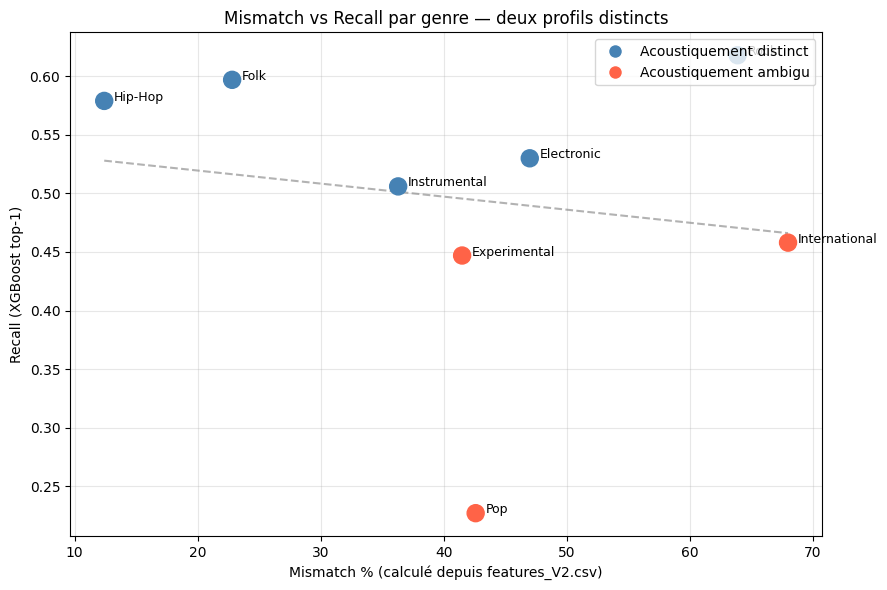

In [15]:
# C14
# 13. Scatter mismatch vs recall — visualisation hypothèse NB1

# Redéfinitions pour indépendance de la cellule (protocole mandatory)
y_true = y_test.values
y_pred = y_pred_top1

report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

scatter_df = pd.DataFrame({
    'Genre'      : list(mismatch_by_genre.index),
    'Mismatch_%' : list(mismatch_by_genre.values.round(1)),
    'Recall'     : [round(report_dict.get(g, {}).get('recall', 0), 3) for g in mismatch_by_genre.index],
    'F1'         : [round(report_dict.get(g, {}).get('f1-score', 0), 3) for g in mismatch_by_genre.index],
}).sort_values('Mismatch_%')

corr = scatter_df[['Mismatch_%', 'Recall']].corr().iloc[0, 1]
print("=== SCATTER MISMATCH vs RECALL ===")
print(scatter_df.to_string(index=False))
print(f"\nCorrélation Mismatch / Recall : {corr:.3f}")
print("→ Corrélation faible mais négative — relation non linéaire")
print("→ Deux groupes distincts : genres acoustiquement forts vs ambigus")

# Deux groupes : acoustiquement distincts vs ambigus
groupe_fort  = ['Folk', 'Rock', 'Hip-Hop', 'Electronic', 'Instrumental']
groupe_ambigu = ['Pop', 'Experimental', 'International']

couleurs = ['steelblue' if g in groupe_fort else 'tomato' for g in scatter_df['Genre']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter_df['Mismatch_%'], scatter_df['Recall'],
           s=150, c=couleurs, zorder=3)

for _, row in scatter_df.iterrows():
    ax.annotate(row['Genre'], (row['Mismatch_%'], row['Recall']),
                textcoords='offset points', xytext=(7, 0), fontsize=9)

# Droite de régression
z = np.polyfit(scatter_df['Mismatch_%'], scatter_df['Recall'], 1)
p = np.poly1d(z)
xline = np.linspace(scatter_df['Mismatch_%'].min(), scatter_df['Mismatch_%'].max(), 100)
ax.plot(xline, p(xline), '--', color='gray', alpha=0.6, label=f'Régression (r={corr:.2f})')

# Légende manuelle
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='Acoustiquement distinct'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',    markersize=10, label='Acoustiquement ambigu'),
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_xlabel('Mismatch % (calculé depuis features_V2.csv)')
ax.set_ylabel('Recall (XGBoost top-1)')
ax.set_title('Mismatch vs Recall par genre — deux profils distincts')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'mismatch_vs_recall.png', dpi=150)
plt.show()

In [16]:
# C15
# 14. Tableau comparatif final + sauvegarde CSV standard

# Redéfinitions pour indépendance de la cellule
y_true = y_test.values
y_pred = y_pred_top1
bal_acc_top1 = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced accuracy top-1 : {bal_acc_top1:.4f}")

results_final = pd.DataFrame([
    {
        'model'       : 'XGBoost_top1_genre',
        'task'        : 'genre_top classification',
        'f1_test'     : round(f1_top1, 4),
        'acc_test'    : round(acc_top1, 4),
        'bal_acc_test': round(bal_acc_top1, 4),
        'coverage_topk' : None,
        'f1_micro_ml' : None,
        'f1_macro_ml' : None,
        'f1_samples_ml': None,
        'hamming_loss': None,
        'precision_at_3': None,
        'f1_mismatch_coh': round(f1_coh, 4),
        'f1_mismatch_amb': round(f1_amb, 4),
        'seed'        : SEED,
        'split'       : 'GroupShuffleSplit',
        'imputer'     : 'median',
        'scaler'      : 'None',
        'n_features'  : X_train.shape[1],
        'n_train'     : len(train_idx),
        'n_test'      : len(test_idx),
        'dataset'     : 'FMA_Small_V2',
    },
    {
        'model'       : f'XGBoost_top{K}_genre',
        'task'        : f'top-{K} coverage genre_top',
        'f1_test'     : round(f1_top1, 4),
        'acc_test'    : round(acc_top1, 4),
        'coverage_topk' : round(coverage_topk, 4),
        'f1_micro_ml' : None,
        'f1_macro_ml' : None,
        'f1_samples_ml': None,
        'hamming_loss': None,
        'precision_at_3': None,
        'f1_mismatch_coh': round(f1_coh, 4),
        'f1_mismatch_amb': round(f1_amb, 4),
        'seed'        : SEED,
        'split'       : 'GroupShuffleSplit',
        'imputer'     : 'median',
        'scaler'      : 'None',
        'n_features'  : X_train.shape[1],
        'n_train'     : len(train_idx),
        'n_test'      : len(test_idx),
        'dataset'     : 'FMA_Small_V2',
    },
    {
        'model'       : 'XGBoost_OneVsRest_multilabel',
        'task'        : 'multi-label sous-genres',
        'f1_test'     : None,
        'acc_test'    : None,
        'coverage_topk' : None,
        'f1_micro_ml' : round(f1_micro, 4),
        'f1_macro_ml' : round(f1_macro, 4),
        'f1_samples_ml': round(f1_samples, 4),
        'hamming_loss': round(h_loss, 4),
        'precision_at_3': round(p_at_3, 4),
        'f1_mismatch_coh': None,
        'f1_mismatch_amb': None,
        'seed'        : SEED,
        'split'       : 'GroupShuffleSplit',
        'imputer'     : 'median',
        'scaler'      : 'None',
        'n_features'  : X_train.shape[1],
        'n_train'     : len(train_idx),
        'n_test'      : len(test_idx),
        'dataset'     : 'FMA_Small_V2',
    },
])

print("=== TABLEAU COMPARATIF FINAL ===")
print(results_final.to_string(index=False))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
results_final.to_csv(OUTPUT_DIR / 'results_nb5.csv', index=False)
print(f"\nRésultats sauvegardés : {OUTPUT_DIR / 'results_nb5.csv'}")


Balanced accuracy top-1 : 0.4952
=== TABLEAU COMPARATIF FINAL ===
                       model                     task  f1_test  acc_test  bal_acc_test  coverage_topk  f1_micro_ml  f1_macro_ml  f1_samples_ml  hamming_loss  precision_at_3  f1_mismatch_coh  f1_mismatch_amb  seed             split imputer scaler  n_features  n_train  n_test      dataset
          XGBoost_top1_genre genre_top classification   0.4929    0.5016        0.4952            NaN          NaN          NaN            NaN           NaN             NaN            0.498           0.4234    42 GroupShuffleSplit  median   None         351     6477    1517 FMA_Small_V2
          XGBoost_top3_genre top-3 coverage genre_top   0.4929    0.5016           NaN         0.8214          NaN          NaN            NaN           NaN             NaN            0.498           0.4234    42 GroupShuffleSplit  median   None         351     6477    1517 FMA_Small_V2
XGBoost_OneVsRest_multilabel  multi-label sous-genres      NaN       N

---

### Analyse — Résultats

#### Top-k (k=3)

Top-1 F1 macro = 0.493, cohérent avec NB3 (Diego, split identique confirmé).
Top-3 coverage = 82.1% : dans 82% des cas, le vrai genre est parmi les 3 premiers candidats.
Gain de +32.0 pts vs top-1 — argument fort pour une application de recommandation
où présenter plusieurs options est acceptable.

Pop est le genre le plus difficile (recall top-1 = 0.23, coverage top-3 = 0.76) :
ses features acoustiques chevauchent plusieurs genres, indépendamment du mismatch.

#### Hypothèse mismatch (NB1)

Corrélation mismatch/recall : **-0.167** — faible en valeur absolue, mais le
graphique révèle une structure en deux groupes bien plus informative :

- **Genres acoustiquement distincts** (Folk, Rock, Hip-Hop, Electronic, Instrumental) :
  recall entre 0.51 et 0.62, indépendamment du taux de mismatch.
  Rock atteint 0.62 de recall malgré 63.9% de mismatch.

- **Genres acoustiquement ambigus** (Pop, Experimental, International) :
  recall entre 0.23 et 0.46, même avec un mismatch modéré.
  Pop échoue (0.23) non pas à cause du mismatch, mais parce que
  ses features acoustiques chevauchent tous les autres genres.

Conclusion : **le mismatch n'est pas le facteur limitant principal**.
Ce sont les features acoustiques intrinsèques de chaque genre qui déterminent
la performance. Un genre acoustiquement fort résiste au mismatch ;
un genre acoustiquement ambigu échoue même sans mismatch.

#### Multi-label sous-genres

F1 micro = 0.166, F1 macro = 0.114 — performances limitées mais attendues :
la tâche est nettement plus difficile (28 classes, distribution déséquilibrée).

Point clé : **Hamming loss = 0.040** — le modèle ne prédit pas n'importe quoi.
Sur 28 sous-genres possibles, seulement 4% des prédictions binaires sont fausses.

8 sous-genres sur 28 ont un F1 = 0.000 (Rock, Experimental Pop, Indie-Rock,
Synth Pop, Dubstep, Ambient Electronic, Chill-out) : acoustiquement proches
d'autres classes, XGBoost tabulaire ne parvient pas à les discriminer.

Precision@3 = 0.207 : parmi les 3 sous-genres proposés, 1 sur 5 est correct en moyenne.

---


---

## Conclusion

---

### Résultats

| Approche | Métrique | Valeur |
|---|---|---|
| genre_top top-1 | F1 macro | 0.493 |
| genre_top top-1 | Accuracy | 0.502 |
| top-3 coverage genre | Coverage | 0.821 (82.1%) |
| Cohérents (mismatch=0) | F1 macro | 0.498 |
| Ambigus (mismatch=1) | F1 macro | 0.423 |
| multi-label (28 sous-genres) | F1 micro | 0.166 |
| multi-label (28 sous-genres) | F1 macro | 0.114 |
| multi-label (28 sous-genres) | F1 samples | 0.087 |
| multi-label (28 sous-genres) | Hamming loss | 0.040 |
| multi-label (28 sous-genres) | Precision@3 | 0.207 |

---

### Décisions transmises

| Décision | Valeur |
|---|---|
| Approche recommandée | Top-k (k=3) — meilleur compromis performance/utilité |
| Hypothèse mismatch | Partiellement confirmée — différence F1 +0.075, mais relation non linéaire |
| Facteur limitant principal | Features acoustiques intrinsèques (pas le mismatch) |
| Sous-genres éligibles | 28 (seuil ≥ 100 occurrences sur train) |
| Plafond tabulaire | F1 macro ~0.493 |

---